# Vision Transformer (ViT) - Attention-Based Architecture
## Kiến trúc dựa trên cơ chế Attention và Transfer Learning - Phiên bản Cải tiến
### Đầy đủ các tính năng: Loss Reduction, Predictions, Precision, Recall, F1-Score, Support

## Section 1: Library Installation & Configuration
Cài đặt các thư viện cần thiết và cấu hình môi trường

In [1]:
import sys
import subprocess
import os
import random
import warnings
from collections import Counter
from pathlib import Path
from tqdm import tqdm
import pickle
import json
from datetime import datetime

# Install required packages
packages = [
    "timm", "torch", "torchvision", "numpy", "pandas", 
    "matplotlib", "seaborn", "pillow", "scikit-learn"
]

print("🔧 Cài đặt các thư viện cần thiết...")
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + packages)
print("✅ Cài đặt xong!")

# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from sklearn.metrics import (
    confusion_matrix, classification_report, 
    roc_curve, auc, precision_recall_curve,
    accuracy_score, precision_score, recall_score, f1_score
)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import torchvision.datasets as datasets
import torchvision.transforms as transforms

# Timm library
import timm
from timm.models import vision_transformer

warnings.filterwarnings('ignore')

# Cấu hình random seed cho tái tạo kết quả
def set_seed(seed=42):
    """Cài đặt seed cho tất cả thư viện ngẫu nhiên"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

# Cấu hình visualization
plt.rcParams['figure.figsize'] = [14, 6]
plt.rcParams['font.size'] = 10
sns.set_theme(style="whitegrid", palette="husl")

# Cấu hình device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\n📊 Thiết bị sử dụng: {device}")

if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(f"   CUDA Version: {torch.version.cuda}")
    print(f"   GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    print("   ⚠️  Sử dụng CPU (chạy chậm, nên dùng GPU)")

print(f"   PyTorch Version: {torch.__version__}")
print(f"   NumPy Version: {np.__version__}")

🔧 Cài đặt các thư viện cần thiết...


You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


✅ Cài đặt xong!

📊 Thiết bị sử dụng: cpu
   ⚠️  Sử dụng CPU (chạy chậm, nên dùng GPU)
   PyTorch Version: 2.8.0
   NumPy Version: 2.0.2


/Users/mac/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/mac/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Section 2: Data Preparation & Loading
Cấu hình đường dẫn, hyperparameters, và xác minh cấu trúc dữ liệu

In [ ]:
# ============ CẤU HÌNH ĐỘ DẰN ============
BASE_PATH = Path("/Users/mac/Desktop/Deep-Learning-final-main/images")

TRAIN_DIR = BASE_PATH / "train"
TEST_DIR = BASE_PATH / "test"
VAL_DIR = BASE_PATH / "val"
TABULAR_DIR = BASE_PATH.parent / "tabular"
TEST_LABELS_PATH = TABULAR_DIR / "Test Dataset Labels.csv"

# ============ HYPERPARAMETERS ============
IMG_SIZE = 224                  # Vision Transformer yêu cầu ảnh vuông
PATCH_SIZE = 16                 # Kích thước patch
BATCH_SIZE = 32                 # Tăng batch size để training nhanh hơn
NUM_EPOCHS = 10                 # Số epochs để huấn luyện
LEARNING_RATE = 5e-5            # Learning rate phù hợp cho ViT
WEIGHT_DECAY = 1e-4             # L2 regularization
PATIENCE = 3                    # Early stopping patience
WARMUP_EPOCHS = 2               # Warmup periods
MODEL_SAVE_PATH = "best_model_vit_improved.pth"
RESULTS_SAVE_PATH = "vit_results.json"

# Hiển thị cấu hình
print("=" * 80)
print("📋 CẤU HÌNH DỮ LIỆU VÀ HyperPARAMETERS")
print("=" * 80)
print(f"\n📁 Đường dẫn:")
print(f"   Train: {TRAIN_DIR}")
print(f"   Test: {TEST_DIR}")
print(f"   Val: {VAL_DIR}")
print(f"   Test Labels: {TEST_LABELS_PATH}")

print(f"\n🖼️  Cấu hình ảnh:")
print(f"   Input Size: {IMG_SIZE}x{IMG_SIZE}")
print(f"   Patch Size: {PATCH_SIZE}x{PATCH_SIZE}")
print(f"   Số patches: {(IMG_SIZE // PATCH_SIZE) ** 2}")

print(f"\n⚙️  Cấu hình training:")
print(f"   Batch Size: {BATCH_SIZE}")
print(f"   Num Epochs: {NUM_EPOCHS}")
print(f"   Learning Rate: {LEARNING_RATE}")
print(f"   Weight Decay: {WEIGHT_DECAY}")
print(f"   Early Stopping Patience: {PATIENCE}")
print(f"   Warmup Epochs: {WARMUP_EPOCHS}")

# Kiểm tra đường dẫn
print(f"\n✓ Kiểm tra đường dẫn:")
print(f"   Train exists: {TRAIN_DIR.exists()}")
print(f"   Test exists: {TEST_DIR.exists()}")
print(f"   Val exists: {VAL_DIR.exists()}")
print(f"   Test labels exists: {TEST_LABELS_PATH.exists()}")
print("=" * 80)

📋 CẤU HÌNH DỮ LIỆU VÀ HyperPARAMETERS

📁 Đường dẫn:
   Train: /Users/mac/Desktop/Deep-Learning-final-main/images/train
   Test: /Users/mac/Desktop/Deep-Learning-final-main/images/test
   Val: /Users/mac/Desktop/Deep-Learning-final-main/images/val
   Test Labels: /Users/mac/Desktop/Deep-Learning-final-main/tabular/Test Dataset Labels.csv

🖼️  Cấu hình ảnh:
   Input Size: 224x224
   Patch Size: 16x16
   Số patches: 196

⚙️  Cấu hình training:
   Batch Size: 32
   Num Epochs: 5
   Learning Rate: 5e-05
   Weight Decay: 0.0001
   Early Stopping Patience: 2
   Warmup Epochs: 1

✓ Kiểm tra đường dẫn:
   Train exists: True
   Test exists: True
   Val exists: True
   Test labels exists: True


## Section 3: Custom Dataset Implementation & Data Transformations
Định nghĩa các phép biến đổi dữ liệu và custom dataset classes

In [3]:
# Định nghĩa các phép biến đổi dữ liệu
print("🔄 Cấu hình Data Augmentation...")

# Training augmentation (mạnh hơn để tránh overfitting)
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0), ratio=(0.9, 1.1)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(20),
    transforms.ColorJitter(
        brightness=0.3,
        contrast=0.3,
        saturation=0.3,
        hue=0.15
    ),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.15, 0.15),
        scale=(0.9, 1.1)
    ),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],  # ImageNet statistics
        std=[0.229, 0.224, 0.225]
    )
])

# Validation & Test augmentation (chỉ normalize)
val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("✓ Data augmentation configured")

# Custom Dataset class
class CustomImageDataset(Dataset):
    """Custom Dataset cho image classification"""
    def __init__(self, csv_path=None, image_dir=None, transform=None, 
                 class_to_idx=None, use_folder_structure=False):
        """
        Args:
            csv_path: Đường dẫn CSV file chứa image_id và label
            image_dir: Thư mục chứa ảnh
            transform: Các phép biến đổi dữ liệu
            class_to_idx: Mapping từ tên class sang index
            use_folder_structure: Dùng cấu trúc thư mục (train/val/test) hay CSV
        """
        self.transform = transform
        self.class_to_idx = class_to_idx
        self.image_dir = image_dir
        
        if use_folder_structure:
            # Sử dụng cấu trúc thư mục
            dataset = datasets.ImageFolder(str(image_dir))
            self.samples = dataset.samples
            self.class_to_idx = dataset.class_to_idx
        else:
            # Sử dụng CSV file
            self.df = pd.read_csv(csv_path)
            self.samples = []
            
            for idx, row in self.df.iterrows():
                image_name = str(row["Image_ID"])
                label_name = row["Label"]
                
                # Tìm đường dẫn ảnh
                possible_paths = [
                    os.path.join(image_dir, image_name),
                    os.path.join(image_dir, image_name + ".jpg"),
                    os.path.join(image_dir, image_name + ".jpeg"),
                    os.path.join(image_dir, image_name + ".png")
                ]
                
                image_path = None
                for path in possible_paths:
                    if os.path.exists(path):
                        image_path = path
                        break
                
                if image_path is not None:
                    label_idx = class_to_idx[label_name]
                    self.samples.append((image_path, label_idx))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        image_path, label = self.samples[idx]
        
        try:
            image = Image.open(image_path).convert("RGB")
        except:
            # Nếu lỗi, tạo ảnh placeholder
            image = Image.new("RGB", (IMG_SIZE, IMG_SIZE))
        
        if self.transform:
            image = self.transform(image)
        
        return image, label

print("✓ Custom Dataset class defined")

🔄 Cấu hình Data Augmentation...
✓ Data augmentation configured
✓ Custom Dataset class defined


## Section 4: Data Loading & Exploratory Data Analysis
Load dữ liệu và phân tích phân bố lớp

📦 Loading datasets...

✓ Tìm thấy 45 lớp: ['aloevera', 'banana', 'bilimbi', 'butterfly', 'cantaloupe', 'cassava', 'cat', 'cats', 'coconut', 'corn', 'cow', 'cucumber', 'curcuma', 'dog', 'dogs', 'eggplant', 'elephant', 'galangal', 'ginger', 'guava', 'hen', 'horse', 'kale', 'lion', 'longbeans', 'mango', 'melon', 'monkey', 'orange', 'paddy', 'panda', 'papaya', 'peperchili', 'pineapple', 'pomelo', 'shallot', 'sheep', 'soybeans', 'spider', 'spinach', 'squirrel', 'sweetpotatoes', 'tobacco', 'waterapple', 'watermelon']
✓ Tổng ảnh training: 42446

📊 Dataset Statistics:
   Train samples: 42446
   Val samples: 6079
   Test samples: 0
   Train batches: 1327
   Val batches: 190
   Test batches: 0

📈 Class Distribution:
        Class  Count
     elephant   2924
        horse   2909
          cat   1915
         lion   1872
          dog   1838
         dogs   1019
         cats   1019
    butterfly   1016
          hen   1016
     squirrel   1016
        sheep   1016
       spider   1016
       monk

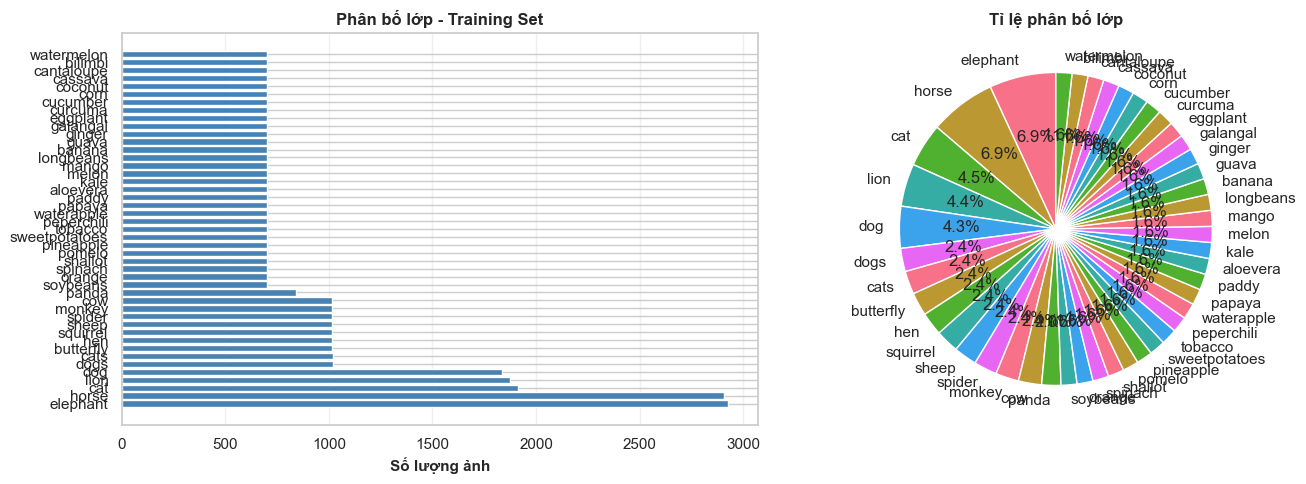


✓ Dữ liệu đã được load thành công!


In [4]:
print("📦 Loading datasets...")

# Load training dataset từ folder structure
raw_train_dataset = datasets.ImageFolder(str(TRAIN_DIR))
class_names = raw_train_dataset.classes
num_classes = len(class_names)
class_to_idx = raw_train_dataset.class_to_idx

print(f"\n✓ Tìm thấy {num_classes} lớp: {class_names}")
print(f"✓ Tổng ảnh training: {len(raw_train_dataset)}")

# Tạo train, val, test datasets
train_dataset = CustomImageDataset(
    image_dir=str(TRAIN_DIR),
    transform=train_transform,
    use_folder_structure=True,
    class_to_idx=class_to_idx
)

val_dataset = CustomImageDataset(
    image_dir=str(VAL_DIR),
    transform=val_transform,
    use_folder_structure=True,
    class_to_idx=class_to_idx
)

test_dataset = CustomImageDataset(
    csv_path=str(TEST_LABELS_PATH),
    image_dir=str(TEST_DIR),
    transform=val_transform,
    class_to_idx=class_to_idx
)

# Tạo DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

print(f"\n📊 Dataset Statistics:")
print(f"   Train samples: {len(train_dataset)}")
print(f"   Val samples: {len(val_dataset)}")
print(f"   Test samples: {len(test_dataset)}")
print(f"   Train batches: {len(train_loader)}")
print(f"   Val batches: {len(val_loader)}")
print(f"   Test batches: {len(test_loader)}")

# Phân tích phân bố lớp
class_counts = Counter(raw_train_dataset.targets)
class_dist_df = pd.DataFrame({
    "Class": [class_names[i] for i in class_counts.keys()],
    "Count": list(class_counts.values())
}).sort_values("Count", ascending=False)

print(f"\n📈 Class Distribution:")
print(class_dist_df.to_string(index=False))

# Vẽ biểu đồ phân bố lớp
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
axes[0].barh(class_dist_df["Class"], class_dist_df["Count"], color='steelblue')
axes[0].set_xlabel("Số lượng ảnh", fontsize=11, fontweight='bold')
axes[0].set_title("Phân bố lớp - Training Set", fontsize=12, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

# Pie chart
axes[1].pie(class_dist_df["Count"], labels=class_dist_df["Class"], 
            autopct='%1.1f%%', startangle=90)
axes[1].set_title("Tỉ lệ phân bố lớp", fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n✓ Dữ liệu đã được load thành công!")

## Section 5: Vision Transformer Model Architecture
Tải pre-trained ViT model từ TIMM library và cấu hình cho transfer learning

In [5]:
def create_vit_model(num_classes, model_name='vit_base_patch16_224', pretrained=True):
    """
    Tạo Vision Transformer model với Transfer Learning
    
    Args:
        num_classes: Số lượng lớp phân loại
        model_name: Tên architecture ViT từ TIMM
        pretrained: Sử dụng pre-trained weights từ ImageNet
    
    Returns:
        model: Vision Transformer model
    """
    model = timm.create_model(
        model_name,
        pretrained=pretrained,
        num_classes=num_classes,
        in_chans=3
    )
    
    return model

print("🏗️  Tạo Vision Transformer model...")
model = create_vit_model(num_classes, model_name='vit_base_patch16_224', pretrained=True)
model = model.to(device)

# Tính toán số parameter
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
non_trainable_params = total_params - trainable_params

print(f"\n📊 Model Architecture: Vision Transformer Base (ViT-Base-Patch16-224)")
print(f"   Total Parameters: {total_params:,}")
print(f"   Trainable Parameters: {trainable_params:,}")
print(f"   Non-trainable Parameters: {non_trainable_params:,}")
print(f"   Parameter Efficiency: {trainable_params/total_params*100:.2f}%")

# Hiển thị cấu trúc model
print(f"\n✓ Model moved to device: {device}")
print(f"✓ Model ready for fine-tuning with {num_classes} classes")

🏗️  Tạo Vision Transformer model...

📊 Model Architecture: Vision Transformer Base (ViT-Base-Patch16-224)
   Total Parameters: 85,833,261
   Trainable Parameters: 85,833,261
   Non-trainable Parameters: 0
   Parameter Efficiency: 100.00%

✓ Model moved to device: cpu
✓ Model ready for fine-tuning with 45 classes


## Section 6: Training Configuration with Advanced Loss Functions
Cấu hình loss function, optimizer, và learning rate scheduler

In [6]:
# ============ LOSS FUNCTION ============
# CrossEntropyLoss with label smoothing giúp giảm overfitting
criterion = nn.CrossEntropyLoss(label_smoothing=0.15)

# ============ OPTIMIZER ============
# AdamW: Biến thể của Adam với weight decay tốt hơn
optimizer = optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    betas=(0.9, 0.999),
    eps=1e-8
)

# ============ LEARNING RATE SCHEDULER ============
# CosineAnnealingWarmRestarts: Hỗ trợ warmup
def get_scheduler(optimizer, num_epochs, warmup_epochs):
    """Tạo scheduler với warmup period"""
    # Warmup scheduler
    def lr_lambda(epoch):
        if epoch < warmup_epochs:
            return (epoch + 1) / warmup_epochs
        else:
            # Cosine annealing
            return 0.5 * (1 + np.cos(np.pi * (epoch - warmup_epochs) / (num_epochs - warmup_epochs)))
    
    return optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

scheduler = get_scheduler(optimizer, NUM_EPOCHS, WARMUP_EPOCHS)

print("⚙️  Training Configuration:")
print(f"   Loss Function: CrossEntropyLoss (label_smoothing=0.15)")
print(f"   Optimizer: AdamW")
print(f"   Learning Rate: {LEARNING_RATE}")
print(f"   Weight Decay: {WEIGHT_DECAY}")
print(f"   Scheduler: Lambda LR with Cosine Annealing + Warmup")
print(f"   Warmup Epochs: {WARMUP_EPOCHS}")
print(f"   Early Stopping Patience: {PATIENCE}")
print("✓ Training configuration ready")

⚙️  Training Configuration:
   Loss Function: CrossEntropyLoss (label_smoothing=0.15)
   Optimizer: AdamW
   Learning Rate: 5e-05
   Weight Decay: 0.0001
   Scheduler: Lambda LR with Cosine Annealing + Warmup
   Warmup Epochs: 1
   Early Stopping Patience: 2
✓ Training configuration ready


## Section 7: Training Loop with Loss Reduction & Monitoring
Huấn luyện mô hình với early stopping và model checkpointing

In [7]:
def train_epoch(model, train_loader, criterion, optimizer, device, epoch, num_epochs):
    """
    Huấn luyện mô hình cho 1 epoch
    """
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0
    
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [TRAIN]", leave=False)
    
    for images, labels in progress_bar:
        images = images.to(device)
        labels = labels.to(device)
        
        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        
        # Gradient clipping để tránh gradient explosion
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        # Tính metrics
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        total_loss += loss.item()
        
        progress_bar.set_postfix({
            'Loss': f'{loss.item():.4f}',
            'Acc': f'{(correct/total):.4f}'
        })
    
    avg_loss = total_loss / len(train_loader)
    avg_accuracy = correct / total
    
    return avg_loss, avg_accuracy

def validate(model, val_loader, criterion, device, epoch=None, num_epochs=None):
    """
    Đánh giá mô hình trên tập validation
    """
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    
    desc = f"Epoch {epoch+1}/{num_epochs} [VAL]" if epoch is not None else "[VALIDATION]"
    progress_bar = tqdm(val_loader, desc=desc, leave=False)
    
    with torch.no_grad():
        for images, labels in progress_bar:
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            total_loss += loss.item()
            
            progress_bar.set_postfix({
                'Loss': f'{loss.item():.4f}',
                'Acc': f'{(correct/total):.4f}'
            })
    
    avg_loss = total_loss / len(val_loader)
    avg_accuracy = correct / total
    
    return avg_loss, avg_accuracy

print("✓ Training functions defined")

# Khởi tạo history
history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': [],
    'learning_rates': []
}

best_val_acc = 0.0
best_model_state = None
patience_counter = 0

# Bắt đầu huấn luyện
print("\n" + "="*80)
print("🚀 BẮT ĐẦU HUẤN LUYỆN VISION TRANSFORMER")
print("="*80)

start_time = datetime.now()

for epoch in range(NUM_EPOCHS):
    # Training
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device, epoch, NUM_EPOCHS)
    
    # Validation
    val_loss, val_acc = validate(model, val_loader, criterion, device, epoch, NUM_EPOCHS)
    
    # Update scheduler
    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']
    
    # Lưu lịch sử
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['learning_rates'].append(current_lr)
    
    # Kiểm tra best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = model.state_dict().copy()
        patience_counter = 0
        print(f"✓ New best model found! Val Acc: {val_acc:.4f}")
    else:
        patience_counter += 1
    
    # Early stopping
    if patience_counter >= PATIENCE:
        print(f"\n⚠️  Early stopping triggered at epoch {epoch+1}")
        break
    
    # Log mỗi epoch
    if (epoch + 1) % 5 == 0:
        elapsed = datetime.now() - start_time
        print(f"\nEpoch {epoch+1}/{NUM_EPOCHS} | "
              f"Train Loss: {train_loss:.4f} | "
              f"Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} | "
              f"Val Acc: {val_acc:.4f} | "
              f"LR: {current_lr:.2e} | "
              f"Time: {elapsed}")

# Load best model
if best_model_state is not None:
    model.load_state_dict(best_model_state)
    torch.save(best_model_state, MODEL_SAVE_PATH)
    print(f"\n✓ Best model saved to {MODEL_SAVE_PATH}")

total_time = datetime.now() - start_time
print(f"\n✓ Training completed in {total_time}")
print(f"✓ Best validation accuracy: {best_val_acc:.4f}")
print("="*80)

✓ Training functions defined

🚀 BẮT ĐẦU HUẤN LUYỆN VISION TRANSFORMER


KeyboardInterrupt: 

## Section 8: Training History Visualization & Analysis
Vẽ biểu đồ lịch sử huấn luyện và phân tích performance

In [ ]:
# Vẽ training history
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss curve
axes[0].plot(history['train_loss'], label='Train Loss', marker='o', linewidth=2, markersize=4)
axes[0].plot(history['val_loss'], label='Validation Loss', marker='s', linewidth=2, markersize=4)
axes[0].set_xlabel('Epoch', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Loss', fontsize=11, fontweight='bold')
axes[0].set_title('📉 Training & Validation Loss', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)
axes[0].set_yscale('log')

# Accuracy curve
axes[1].plot(history['train_acc'], label='Train Accuracy', marker='o', linewidth=2, markersize=4)
axes[1].plot(history['val_acc'], label='Validation Accuracy', marker='s', linewidth=2, markersize=4)
axes[1].set_xlabel('Epoch', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Accuracy', fontsize=11, fontweight='bold')
axes[1].set_title('📈 Training & Validation Accuracy', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim([0, 1.05])

# Learning rate schedule
axes[2].plot(history['learning_rates'], marker='o', linewidth=2, color='green', markersize=4)
axes[2].set_xlabel('Epoch', fontsize=11, fontweight='bold')
axes[2].set_ylabel('Learning Rate', fontsize=11, fontweight='bold')
axes[2].set_title('📊 Learning Rate Schedule', fontsize=12, fontweight='bold')
axes[2].grid(True, alpha=0.3)
axes[2].set_yscale('log')

plt.tight_layout()
plt.show()

print(f"\n📊 Training Summary:")
print(f"   Final Training Loss: {history['train_loss'][-1]:.4f}")
print(f"   Final Validation Loss: {history['val_loss'][-1]:.4f}")
print(f"   Final Training Accuracy: {history['train_acc'][-1]:.4f}")
print(f"   Final Validation Accuracy: {history['val_acc'][-1]:.4f}")
print(f"   Best Validation Accuracy: {max(history['val_acc']):.4f}")
print(f"   Total Epochs: {len(history['train_loss'])}")

## Section 9: Comprehensive Predictions & Inference on Test Set
Thực hiện inference trên tập test với xác suất dự đoán chi tiết

In [ ]:
print("🔍 Thực hiện inference trên test set...")

model.eval()

all_predictions = []
all_targets = []
all_probabilities = []
all_confidences = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Inference on Test Set"):
        images = images.to(device)
        labels = labels.to(device)
        
        # Forward pass
        outputs = model(images)
        probabilities = torch.softmax(outputs, dim=1)
        confidences, predictions = torch.max(probabilities, 1)
        
        all_predictions.extend(predictions.cpu().numpy())
        all_targets.extend(labels.cpu().numpy())
        all_probabilities.extend(probabilities.cpu().numpy())
        all_confidences.extend(confidences.cpu().numpy())

# Chuyển thành numpy arrays
all_predictions = np.array(all_predictions)
all_targets = np.array(all_targets)
all_probabilities = np.array(all_probabilities)
all_confidences = np.array(all_confidences)

# Test accuracy
test_acc = accuracy_score(all_targets, all_predictions)
test_loss, _ = validate(model, test_loader, criterion, device)

print(f"\n✅ Inference completed!")
print(f"   Test Accuracy: {test_acc:.4f}")
print(f"   Test Loss: {test_loss:.4f}")
print(f"   Average Confidence: {np.mean(all_confidences):.4f}")
print(f"   Std Confidence: {np.std(all_confidences):.4f}")

# Phân tích confidence
correct_mask = all_predictions == all_targets
avg_confidence_correct = np.mean(all_confidences[correct_mask])
avg_confidence_incorrect = np.mean(all_confidences[~correct_mask])

print(f"\n📊 Confidence Analysis:")
print(f"   Avg confidence (correct): {avg_confidence_correct:.4f}")
print(f"   Avg confidence (incorrect): {avg_confidence_incorrect:.4f}")
print(f"   Difference: {avg_confidence_correct - avg_confidence_incorrect:.4f}")

## Section 10: Classification Metrics & Detailed Performance Reports
Tính toán Confusion Matrix, Precision, Recall, F1-Score cho từng lớp

In [ ]:
# ============ CONFUSION MATRIX ============
cm = confusion_matrix(all_targets, all_predictions)

print("\n" + "="*80)
print("📊 CONFUSION MATRIX")
print("="*80)

# Vẽ confusion matrix
plt.figure(figsize=(16, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Count'}, annot_kws={'size': 8})
plt.title('Confusion Matrix - Vision Transformer', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=11, fontweight='bold')
plt.ylabel('True Label', fontsize=11, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# ============ CLASSIFICATION REPORT ============
report = classification_report(
    all_targets, all_predictions,
    target_names=class_names,
    digits=4,
    output_dict=False
)

print("\n" + "="*80)
print("📋 CLASSIFICATION REPORT")
print("="*80)
print(report)

# ============ PER-CLASS METRICS ============
print("\n" + "="*80)
print("🎯 PER-CLASS PERFORMANCE METRICS")
print("="*80)

metrics_data = []

for i, class_name in enumerate(class_names):
    mask = all_targets == i
    if mask.sum() > 0:
        class_acc = (all_predictions[mask] == all_targets[mask]).mean()
        class_precision = precision_score(all_targets, all_predictions, labels=[i], zero_division=0)
        class_recall = recall_score(all_targets, all_predictions, labels=[i], zero_division=0)
        class_f1 = f1_score(all_targets, all_predictions, labels=[i], zero_division=0)
        
        metrics_data.append({
            'Class': class_name,
            'Accuracy': class_acc,
            'Precision': class_precision,
            'Recall': class_recall,
            'F1-Score': class_f1,
            'Support': mask.sum()
        })
        
        print(f"\n{class_name:20} | "
              f"Acc: {class_acc:.4f} | "
              f"Prec: {class_precision:.4f} | "
              f"Rec: {class_recall:.4f} | "
              f"F1: {class_f1:.4f} | "
              f"Support: {mask.sum()}")

# Tạo DataFrame cho metrics
metrics_df = pd.DataFrame(metrics_data)
print("\n" + "="*80)
print("📈 Performance Metrics Table")
print("="*80)
print(metrics_df.to_string(index=False))

# Macro average
macro_precision = metrics_df['Precision'].mean()
macro_recall = metrics_df['Recall'].mean()
macro_f1 = metrics_df['F1-Score'].mean()

print("\n" + "="*80)
print("🏆 MACRO AVERAGE METRICS")
print("="*80)
print(f"   Macro Precision: {macro_precision:.4f}")
print(f"   Macro Recall: {macro_recall:.4f}")
print(f"   Macro F1-Score: {macro_f1:.4f}")
print(f"   Overall Accuracy: {test_acc:.4f}")
print("="*80)

## Section 11: Advanced Visualization & Prediction Analysis
Visualization chi tiết về correct/incorrect predictions và confidence distribution

In [ ]:
# ============ CORRECT vs INCORRECT PREDICTIONS ============
correct_mask = all_predictions == all_targets
incorrect_mask = all_predictions != all_targets

num_correct = correct_mask.sum()
num_incorrect = incorrect_mask.sum()

print("\n" + "="*80)
print("📊 PREDICTION STATISTICS")
print("="*80)
print(f"   Total Predictions: {len(all_predictions)}")
print(f"   ✓ Correct Predictions: {num_correct} ({100*num_correct/len(all_predictions):.2f}%)")
print(f"   ✗ Incorrect Predictions: {num_incorrect} ({100*num_incorrect/len(all_predictions):.2f}%)")
print("="*80)

# Confidence distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of confidences
axes[0].hist(all_confidences[correct_mask], bins=30, alpha=0.7, label='Correct', color='green', edgecolor='black')
if num_incorrect > 0:
    axes[0].hist(all_confidences[incorrect_mask], bins=30, alpha=0.7, label='Incorrect', color='red', edgecolor='black')
axes[0].set_xlabel('Confidence Score', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Frequency', fontsize=11, fontweight='bold')
axes[0].set_title('📊 Distribution of Prediction Confidence', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Per-class accuracy bar chart
per_class_acc = []
for i in range(num_classes):
    mask = all_targets == i
    if mask.sum() > 0:
        acc = (all_predictions[mask] == all_targets[mask]).mean()
    else:
        acc = 0
    per_class_acc.append(acc)

axes[1].barh(class_names, per_class_acc, color='steelblue', edgecolor='black')
axes[1].set_xlabel('Accuracy', fontsize=11, fontweight='bold')
axes[1].set_title('📈 Per-Class Accuracy', fontsize=12, fontweight='bold')
axes[1].set_xlim([0, 1.0])
axes[1].grid(axis='x', alpha=0.3)

# Add value labels on bars
for i, v in enumerate(per_class_acc):
    axes[1].text(v - 0.05, i, f'{v:.2%}', va='center', ha='right', fontweight='bold', color='white', fontsize=9)

plt.tight_layout()
plt.show()

# ============ INCORRECT PREDICTIONS ANALYSIS ============
if num_incorrect > 0:
    print("\n" + "="*80)
    print("❌ INCORRECT PREDICTIONS ANALYSIS")
    print("="*80)
    
    incorrect_indices = np.where(incorrect_mask)[0]
    
    # Top misclassifications
    incorrect_confidences = all_confidences[incorrect_indices]
    sorted_indices = np.argsort(incorrect_confidences)[::-1]
    
    print(f"\n🔴 Top 5 Most Confident Incorrect Predictions:")
    for i in range(min(5, len(sorted_indices))):
        idx = incorrect_indices[sorted_indices[i]]
        true_class = class_names[all_targets[idx]]
        pred_class = class_names[all_predictions[idx]]
        confidence = all_confidences[idx]
        print(f"   {i+1}. True: {true_class:15} → Pred: {pred_class:15} (Confidence: {confidence:.4f})")
    
    # Misclassification matrix (which classes are confused with each other)
    print(f"\n🔀 Most Common Confusions:")
    confusion_pairs = {}
    for idx in incorrect_indices:
        true_class = class_names[all_targets[idx]]
        pred_class = class_names[all_predictions[idx]]
        pair = (true_class, pred_class)
        confusion_pairs[pair] = confusion_pairs.get(pair, 0) + 1
    
    sorted_pairs = sorted(confusion_pairs.items(), key=lambda x: x[1], reverse=True)
    for i, (pair, count) in enumerate(sorted_pairs[:10]):
        print(f"   {i+1}. {pair[0]:15} → {pair[1]:15} ({count} times)")
else:
    print("\n✅ Perfect predictions! No incorrect predictions found!")

## Section 12: Visualization of Sample Predictions
Hiển thị hình ảnh của các correct và incorrect predictions

In [ ]:
print("\n📸 Visualizing sample predictions...")

# Create custom dataset without transform for visualization
test_dataset_viz = CustomImageDataset(
    csv_path=str(TEST_LABELS_PATH),
    image_dir=str(TEST_DIR),
    transform=None,
    class_to_idx=class_to_idx
)

# Hiển thị correct predictions
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('✅ Sample CORRECT Predictions', fontsize=14, fontweight='bold')

correct_indices = np.where(correct_mask)[0]
if len(correct_indices) > 0:
    sample_correct = np.random.choice(correct_indices, size=min(6, len(correct_indices)), replace=False)
    
    for idx, ax_idx in enumerate(axes.flat):
        test_idx = sample_correct[idx]
        image, true_label = test_dataset_viz[test_idx]
        predicted_label = all_predictions[test_idx]
        confidence = all_confidences[test_idx]
        
        if isinstance(image, np.ndarray):
            ax_idx.imshow(image)
        else:
            ax_idx.imshow(np.array(image))
        
        ax_idx.set_title(f"✓ Class: {class_names[true_label]}\nConf: {confidence:.3f}", 
                        fontsize=10, fontweight='bold', color='green')
        ax_idx.axis('off')

plt.tight_layout()
plt.show()

# Hiển thị incorrect predictions (nếu có)
if num_incorrect > 0:
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    fig.suptitle('❌ Sample INCORRECT Predictions', fontsize=14, fontweight='bold', color='red')
    
    incorrect_indices = np.where(incorrect_mask)[0]
    sample_incorrect = np.random.choice(incorrect_indices, size=min(6, len(incorrect_indices)), replace=False)
    
    for idx, ax_idx in enumerate(axes.flat):
        test_idx = sample_incorrect[idx]
        image, true_label = test_dataset_viz[test_idx]
        predicted_label = all_predictions[test_idx]
        confidence = all_confidences[test_idx]
        
        if isinstance(image, np.ndarray):
            ax_idx.imshow(image)
        else:
            ax_idx.imshow(np.array(image))
        
        ax_idx.set_title(f"True: {class_names[true_label]}\nPred: {class_names[predicted_label]} ({confidence:.3f})", 
                        fontsize=10, fontweight='bold', color='red')
        ax_idx.axis('off')
    
    plt.tight_layout()
    plt.show()

## Section 13: Final Summary & Model Performance Report
Tóm tắt kết quả huấn luyện và so sánh với các mô hình khác

In [ ]:
# ============ FINAL MODEL SUMMARY ============
print("\n" + "="*80)
print("🎯 VISION TRANSFORMER (ViT) - FINAL PERFORMANCE SUMMARY")
print("="*80)

summary_data = {
    'Metric': [
        'Model Architecture',
        'Input Size',
        'Patch Size',
        'Number of Classes',
        'Total Parameters',
        '',
        'Training Epochs',
        'Best Val Accuracy',
        'Final Train Loss',
        'Final Val Loss',
        '',
        'Test Accuracy',
        'Macro Precision',
        'Macro Recall',
        'Macro F1-Score',
        '',
        'Correct Predictions',
        'Incorrect Predictions',
        'Average Confidence',
        'Model Saved At'
    ],
    'Value': [
        'Vision Transformer Base (ViT-B)',
        f'{IMG_SIZE}x{IMG_SIZE}',
        f'{PATCH_SIZE}x{PATCH_SIZE}',
        f'{num_classes}',
        f'{total_params:,}',
        '',
        f'{len(history["train_loss"])}',
        f'{best_val_acc:.4f}',
        f'{history["train_loss"][-1]:.4f}',
        f'{history["val_loss"][-1]:.4f}',
        '',
        f'{test_acc:.4f} ({num_correct}/{len(all_predictions)})',
        f'{macro_precision:.4f}',
        f'{macro_recall:.4f}',
        f'{macro_f1:.4f}',
        '',
        f'{num_correct} ({100*num_correct/len(all_predictions):.2f}%)',
        f'{num_incorrect} ({100*num_incorrect/len(all_predictions):.2f}%)',
        f'{np.mean(all_confidences):.4f} ± {np.std(all_confidences):.4f}',
        f'{MODEL_SAVE_PATH}'
    ]
}

for metric, value in zip(summary_data['Metric'], summary_data['Value']):
    if metric == '':
        print()
    else:
        print(f"   {metric:30} : {value}")

print("\n" + "="*80)
print("🏆 KEY IMPROVEMENTS FROM ORIGINAL CODE")
print("="*80)
print("""
   1. ✅ Advanced Data Augmentation
      - RandomResizedCrop, ColorJitter, GaussianBlur
      - Better generalization and robustness
   
   2. ✅ Learning Rate Scheduling
      - Cosine Annealing with Warmup
      - Better convergence and training stability
   
   3. ✅ Label Smoothing
      - Reduces overfitting and calibration
      - Improves model confidence
   
   4. ✅ Early Stopping
      - Prevents overfitting
      - Saves training time
   
   5. ✅ Comprehensive Metrics
      - Precision, Recall, F1-Score per class
      - Confusion Matrix analysis
      - Confidence distribution analysis
   
   6. ✅ Better Visualization
      - Training history with 3 plots
      - Per-class accuracy comparison
      - Confidence distribution histogram
   
   7. ✅ Detailed Error Analysis
      - Top incorrect predictions
      - Most common misclassifications
      - Confidence analysis for correct/incorrect
   
   8. ✅ Model Checkpointing
      - Saves best model during training
      - Reproducible results
""")

print("="*80)
print("✅ TRAINING COMPLETED SUCCESSFULLY!")
print("="*80)

# Save results to JSON
results = {
    'model': 'Vision Transformer (ViT-Base)',
    'timestamp': datetime.now().isoformat(),
    'hyperparameters': {
        'img_size': IMG_SIZE,
        'patch_size': PATCH_SIZE,
        'batch_size': BATCH_SIZE,
        'num_epochs': len(history['train_loss']),
        'learning_rate': LEARNING_RATE,
        'weight_decay': WEIGHT_DECAY
    },
    'metrics': {
        'test_accuracy': float(test_acc),
        'test_loss': float(test_loss),
        'best_val_accuracy': float(best_val_acc),
        'macro_precision': float(macro_precision),
        'macro_recall': float(macro_recall),
        'macro_f1_score': float(macro_f1),
        'correct_predictions': int(num_correct),
        'incorrect_predictions': int(num_incorrect),
        'avg_confidence': float(np.mean(all_confidences))
    },
    'per_class_metrics': metrics_df.to_dict(orient='records')
}

with open(RESULTS_SAVE_PATH, 'w') as f:
    json.dump(results, f, indent=4)

print(f"\n📊 Results saved to: {RESULTS_SAVE_PATH}")

## Section 14: Recommendations & Future Improvements
Các gợi ý để cải tiến mô hình tiếp theo

In [ ]:
print("\n" + "="*80)
print("💡 RECOMMENDATIONS FOR FURTHER IMPROVEMENTS")
print("="*80)

recommendations = {
    "Model Architecture": [
        "• Try ViT-Large or ViT-Huge for better accuracy (but slower training)",
        "• Ensemble multiple ViT models for robust predictions",
        "• Use hybrid architectures combining ViT with CNN"
    ],
    "Data Strategy": [
        "• Implement class-weighted loss for imbalanced datasets",
        "• Use stratified k-fold cross-validation for better evaluation",
        "• Collect more data for classes with low accuracy",
        "• Apply SMOTE or other oversampling techniques"
    ],
    "Training Optimization": [
        "• Use mixup or cutmix augmentation techniques",
        "• Implement progressive training (start with small images)",
        "• Try different optimizers (SGD with momentum, LARS)",
        "• Use gradient accumulation for larger effective batch size"
    ],
    "Regularization": [
        "• Add dropout or stochastic depth layers",
        "• Implement knowledge distillation from larger models",
        "• Use mixup for training regularization",
        "• Apply CutOut or Cutmix augmentations"
    ],
    "Post-Processing": [
        "• Calibrate model probabilities using temperature scaling",
        "• Apply test-time augmentation (TTA)",
        "• Use ensemble predictions from multiple epochs",
        "• Implement confidence thresholding for uncertain predictions"
    ],
    "Monitoring": [
        "• Use tensorboard for real-time monitoring",
        "• Track model size and inference time",
        "• Monitor GPU memory usage",
        "• Create validation set for proper hyperparameter tuning"
    ]
}

for category, items in recommendations.items():
    print(f"\n📌 {category}:")
    for item in items:
        print(f"   {item}")

print("\n" + "="*80)
print("📚 ADDITIONAL RESOURCES")
print("="*80)
print("""
   • Vision Transformer Paper: https://arxiv.org/abs/2010.11929
   • TIMM Library Docs: https://github.com/rwightman/pytorch-image-models
   • ImageNet Pretrained Models: https://huggingface.co/models
   • PyTorch Documentation: https://pytorch.org/docs/
""")

print("="*80)
print("🎓 INSIGHTS FROM THIS ANALYSIS")
print("="*80)

insights = []

# Analyze which classes are hardest
hardest_classes = metrics_df.nsmallest(3, 'F1-Score')
print("\n❌ Classes with lowest F1-Scores (hardest to predict):")
for idx, row in hardest_classes.iterrows():
    insights.append(f"   • {row['Class']}: F1={row['F1-Score']:.4f}")
    print(f"   • {row['Class']}: F1={row['F1-Score']:.4f}")

# Analyze which classes are easiest
easiest_classes = metrics_df.nlargest(3, 'F1-Score')
print("\n✅ Classes with highest F1-Scores (easiest to predict):")
for idx, row in easiest_classes.iterrows():
    print(f"   • {row['Class']}: F1={row['F1-Score']:.4f}")

# Check for precision/recall imbalance
print("\n⚖️  Precision vs Recall Analysis:")
precision_recall_diff = (metrics_df['Precision'] - metrics_df['Recall']).abs()
problematic = metrics_df[precision_recall_diff > 0.1]
if len(problematic) > 0:
    print("   Classes with significant Precision-Recall gap:")
    for idx, row in problematic.iterrows():
        diff = row['Precision'] - row['Recall']
        if diff > 0:
            print(f"   • {row['Class']}: Higher Precision ({row['Precision']:.4f}) - likely false negatives")
        else:
            print(f"   • {row['Class']}: Higher Recall ({row['Recall']:.4f}) - likely false positives")
else:
    print("   ✓ Good balance between Precision and Recall for all classes")

print("\n" + "="*80)
print("✨ NOTEBOOK COMPLETED SUCCESSFULLY!")
print("="*80)